##  Basic Library imports

In [5]:
import os
import pandas as pd 
import numpy as np
import csv
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import chi2
import re
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, f1_score, accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns     
import torch
import torch.nn as nn
from torchvision import models, transforms as T
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Running on: {device}")


Running on: cpu


##  Read Dataset

In [6]:
DATASET_FOLDER = '../dataset/'
train = pd.read_csv(os.path.join(DATASET_FOLDER, 'train.csv'))
test = pd.read_csv(os.path.join(DATASET_FOLDER, 'test.csv'))
sample_test = pd.read_csv(os.path.join(DATASET_FOLDER, 'sample_test.csv'))
sample_test_out = pd.read_csv(os.path.join(DATASET_FOLDER, 'sample_test_out.csv'))

In [7]:
from utils import download_images
download_images(sample_test['image_link'], '../images')


100%|██████████| 100/100 [00:30<00:00,  3.25it/s]


In [8]:
assert len(os.listdir('../images')) > 0

In [9]:
rm -rf ../images

## PREPROCESSING AND EDA

In [10]:
DATASET_FOLDER = '../dataset/processed_subset/'
train = pd.read_csv(os.path.join(DATASET_FOLDER, 'train_clean_subset.csv'))
test = pd.read_csv(os.path.join(DATASET_FOLDER, 'test_clean_subset.csv'))

print("DATA LOADED SUCCESSFULLY")

DATA LOADED SUCCESSFULLY


In [11]:
train.info()
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18750 entries, 0 to 18749
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   sample_id        18750 non-null  int64  
 1   catalog_content  18750 non-null  object 
 2   image_link       18750 non-null  object 
 3   price            18750 non-null  float64
 4   clean_text       18750 non-null  object 
dtypes: float64(1), int64(1), object(3)
memory usage: 732.5+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18750 entries, 0 to 18749
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   sample_id        18750 non-null  int64 
 1   catalog_content  18750 non-null  object
 2   image_link       18750 non-null  object
 3   clean_text       18750 non-null  object
dtypes: int64(1), object(3)
memory usage: 586.1+ KB


In [12]:
train.drop_duplicates(inplace=True)
test.drop_duplicates(inplace=True)

In [13]:
train.isnull().sum()
test.isnull().sum()

sample_id          0
catalog_content    0
image_link         0
clean_text         0
dtype: int64

In [15]:
train.dropna(subset=['price'], inplace=True)
train['price'] = pd.to_numeric(train['price'], errors='coerce')

In [16]:
initial_rows = len(train)
train.dropna(subset=['price'], inplace=True)
rows_dropped = initial_rows - len(train)
if rows_dropped > 0:
  print(f"Dropped {rows_dropped} rows with missing prices.")

In [17]:
train['catalog_content'].fillna('Unknown', inplace=True)
test['catalog_content'].fillna('Unknown', inplace=True)

/tmp/ipykernel_37051/2724207420.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train['catalog_content'].fillna('Unknown', inplace=True)
/tmp/ipykernel_37051/2724207420.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=Tr

In [18]:
combined_df = pd.concat([train, test], ignore_index=True)

In [19]:
# Extract Brand Name
brand_pattern = r'Item Name: (\w+)'
combined_df['brand'] = combined_df['catalog_content'].str.extract(brand_pattern, expand=False).fillna('unknown')

# Extract Item Pack Quantity (IPQ)
ipq_pattern = r'(\d+)\s*(?:pack|count|oz|fl oz|g|kg|ml|l)'
combined_df['IPQ'] = combined_df['catalog_content'].str.extract(ipq_pattern, flags=re.IGNORECASE).fillna(1)
combined_df['IPQ'] = pd.to_numeric(combined_df['IPQ'], errors='coerce').fillna(1).astype(int)

# Create text-based features
combined_df['word_count'] = combined_df['catalog_content'].apply(lambda x: len(str(x).split()))
combined_df['char_count'] = combined_df['catalog_content'].apply(lambda x: len(str(x)))

# Create 'clean_text' for NLP models
combined_df['clean_text'] = combined_df['catalog_content'].str.lower().str.replace(r'[^a-z0-9\s]', '', regex=True).str.strip()

print("Engineered Features: 'brand', 'IPQ', 'word_count', 'char_count', 'clean_text'")



Engineered Features: 'brand', 'IPQ', 'word_count', 'char_count', 'clean_text'


In [20]:
train_processed = combined_df[combined_df['price'].notna()].copy()
test_processed = combined_df[combined_df['price'].isna()].copy()

Text(0.5, 0, 'Price')

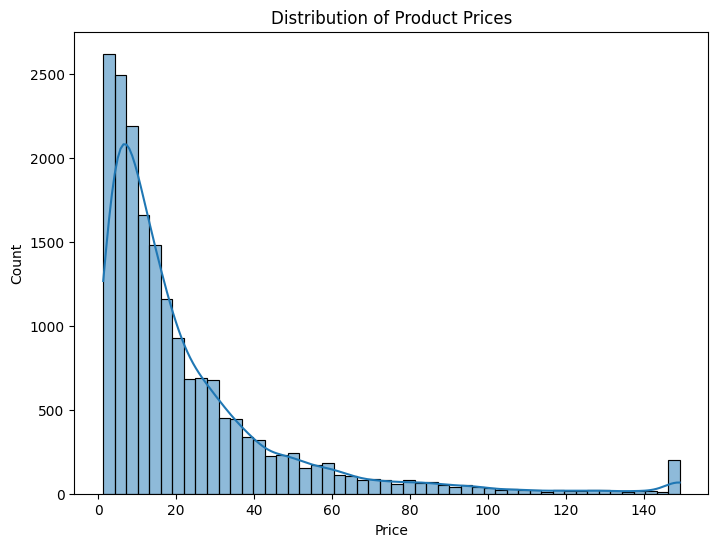

In [21]:
plt.figure(figsize=(18, 6))
plt.subplot(1, 2, 1)
sns.histplot(train_processed['price'], bins=50, kde=True)
plt.title('Distribution of Product Prices')
plt.xlabel('Price')

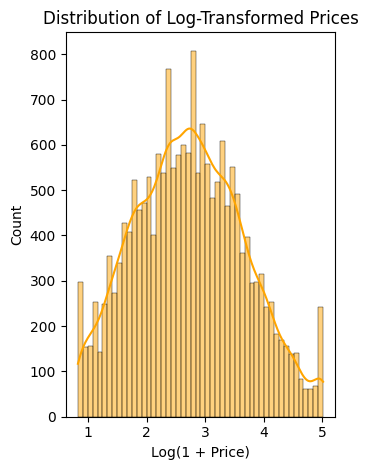

In [22]:
plt.subplot(1, 2, 2)
sns.histplot(np.log1p(train_processed['price']), bins=50, kde=True, color='orange')
plt.title('Distribution of Log-Transformed Prices')
plt.xlabel('Log(1 + Price)')
plt.tight_layout()
plt.show()


--- Correlation Matrix ---
               price       IPQ  word_count  char_count
price       1.000000 -0.005121    0.171737    0.174005
IPQ        -0.005121  1.000000   -0.004439   -0.003777
word_count  0.171737 -0.004439    1.000000    0.997492
char_count  0.174005 -0.003777    0.997492    1.000000


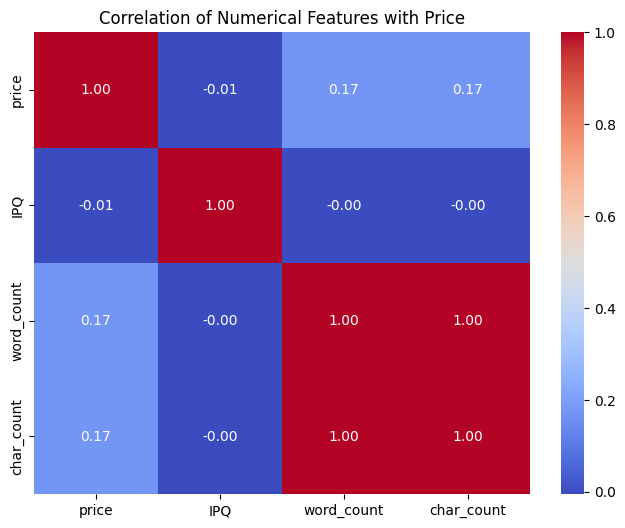

In [23]:
print("\n--- Correlation Matrix ---")
numerical_features = ['price', 'IPQ', 'word_count', 'char_count']
corr_matrix = train_processed[numerical_features].corr()
print(corr_matrix)
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation of Numerical Features with Price')
plt.show()


--- Analyzing Price by Brand (Top 15) ---


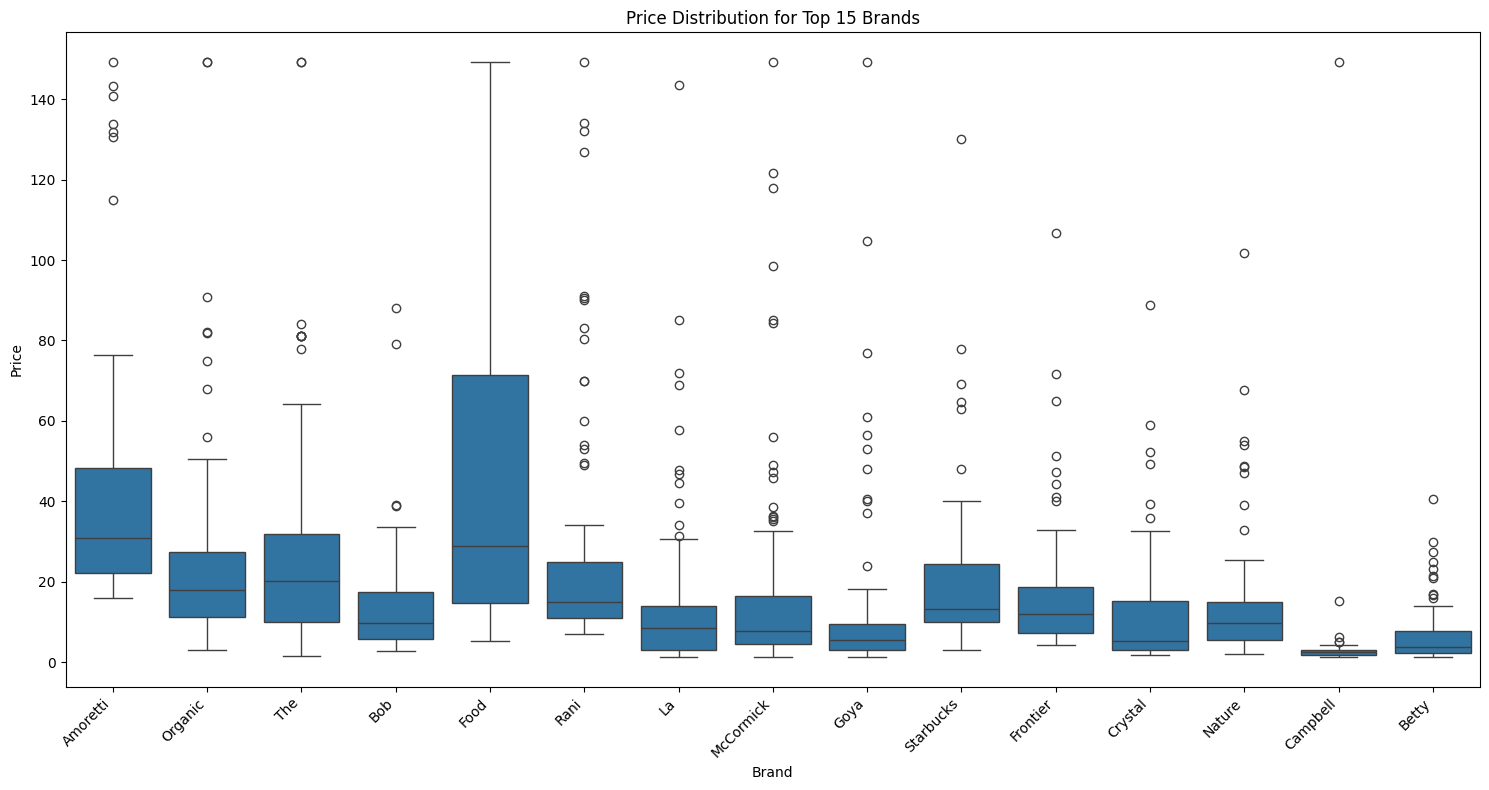


--- Preprocessing and EDA Complete ---


In [24]:
print("\n--- Analyzing Price by Brand (Top 15) ---")
top_brands = train_processed['brand'].value_counts().nlargest(15).index
plt.figure(figsize=(15, 8))
sns.boxplot(data=train_processed[train_processed['brand'].isin(top_brands)], x='brand', y='price')
plt.title('Price Distribution for Top 15 Brands')
plt.xlabel('Brand')
plt.ylabel('Price')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("\n--- Preprocessing and EDA Complete ---")

## Utility Functions


In [ ]:
def get_image_transforms():
    return T.Compose([
        T.Resize((224, 224)),
        T.ToTensor(),
        T.Normalize(mean=[0.485, 0.456, 0.406],
                    std=[0.229, 0.224, 0.225])
    ])


## Model Definitions

In [ ]:
class TextModel(nn.Module):
    def __init__(self, input_dim=300, hidden_dim=128):
        super(TextModel, self).__init__()
        self.fc = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 1)
        )
    
    def forward(self, x):
        return self.fc(x)

class ImageModel(nn.Module):
    def __init__(self):
        super(ImageModel, self).__init__()
        base = models.resnet18(weights="IMAGENET1K_V1")
        for param in base.parameters():
            param.requires_grad = False
        self.feature_extractor = nn.Sequential(*list(base.children())[:-1])
        self.regressor = nn.Linear(base.fc.in_features, 1)
    
    def forward(self, x):
        x = self.feature_extractor(x)
        x = torch.flatten(x, 1)
        return self.regressor(x)


## Pricing Pipeline and Training Helpers

In [28]:
class PricingPipeline:
    """End-to-end pricing prediction pipeline"""
    
    def __init__(self, config=None):
        self.config = config or self._get_default_config()
        self.models = {}
        self.device = device
        self.image_transform = get_image_transforms()
        print(f"Initialized pricing pipeline - Device: {self.device}")
        
    def _get_default_config(self):
        return {
            "models": ["xgboost", "lightgbm", "catboost", "rf", "gbr"],
            "ensemble_type": "mean"
        }
    
    def train_single_model(self, model_name, X_train, y_train):
        if model_name == "xgboost":
            model = XGBRegressor(n_estimators=200, learning_rate=0.1)
        elif model_name == "lightgbm":
            model = LGBMRegressor(n_estimators=200, learning_rate=0.1)
        elif model_name == "catboost":
            model = CatBoostRegressor(verbose=0)
        elif model_name == "rf":
            model = RandomForestRegressor(n_estimators=200)
        elif model_name == "gbr":
            model = GradientBoostingRegressor(n_estimators=200)
        else:
            raise ValueError(f"Unsupported model: {model_name}")
        
        model.fit(X_train, y_train)
        self.models[model_name] = model
        print(f"Trained {model_name} model successfully.")
        return model

    def predict(self, X):
        preds = [model.predict(X) for model in self.models.values()]
        if self.config["ensemble_type"] == "mean":
            return np.mean(preds, axis=0)
        elif self.config["ensemble_type"] == "median":
            return np.median(preds, axis=0)
        else:
            raise ValueError("Unsupported ensemble type")

def quick_train_and_predict(pipeline, X_train, X_val, y_train, y_val):
    for model_name in pipeline.config["models"]:
        pipeline.train_single_model(model_name, X_train, y_train)
    preds = pipeline.predict(X_val)
    mae = mean_absolute_error(y_val, preds)
    print(f"Validation MAE (ensemble): {mae:.4f}")
    return preds, mae


## Train and Validate

In [29]:
feature_cols = ['IPQ', 'word_count', 'char_count']
X = train_processed[feature_cols].values
y = train_processed['price'].values

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

pipeline = PricingPipeline()
preds, mae = quick_train_and_predict(pipeline, X_train, X_val, y_train, y_val)

Initialized pricing pipeline - Device: cpu
Trained xgboost model successfully.
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.026086 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 669
[LightGBM] [Info] Number of data points in the train set: 15000, number of used features: 3
[LightGBM] [Info] Start training from score 22.948599
Trained lightgbm model successfully.
Trained catboost model successfully.
Trained rf model successfully.
Trained gbr model successfully.


/home/pallavi/pallavi_repos/hackathons/Amazon-ML/.venv/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


Validation MAE (ensemble): 16.5740


## Generate Submission File

In [30]:
def generate_submission(pipeline, test_df, output_path="submission.csv"):
    feature_cols = ['IPQ', 'word_count', 'char_count']
    X_test = test_df[feature_cols].values
    predictions = pipeline.predict(X_test)
    submission_df = pd.DataFrame({
        "sample_id": test_df["sample_id"],
        "price": predictions
    })
    submission_df.to_csv(output_path, index=False)
    print(f"✅ Submission file created: {output_path}")
    display(submission_df.head())

generate_submission(pipeline, test_processed)

/home/pallavi/pallavi_repos/hackathons/Amazon-ML/.venv/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


✅ Submission file created: submission.csv


,sample_id,price
18750,217392,27.984538
18751,209156,19.193269
18752,262333,12.928475
18753,295979,19.365053
18754,50604,14.395563
